## 1.import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# split data into train & test
from sklearn.model_selection import train_test_split

# Disable Warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Read Dataset

In [2]:
credit_df = pd.read_csv("https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/credit_train.csv", header = 0, sep = ',')

## 3. Data Manipulation



In [ ]:
# show the first 5 records
credit_df.head()

In [ ]:
# show list of columns
credit_df.columns

In [ ]:
# display shape
credit_df.shape

In [ ]:
# check for null values
credit_df.isnull().sum()

In [ ]:
# show the % of missing records
credit_df.isnull().sum() / credit_df.shape[0] * 100

In [ ]:
# show descriptive summary of sample data
credit_df.describe()

## 4. Handling Missing Values

In [3]:
# Replace Missing delinquent values by 0 ; assuming people have not delinquent in past
credit_df['Months since last delinquent'] = credit_df['Months since last delinquent'].fillna(0)

In [ ]:
credit_df['Credit Score'].unique()

In [ ]:
credit_df['Credit Score'] = credit_df[credit_df['Credit Score'] >= 900]['Credit Score'] / 10

In [4]:
# Fill missing credit score value by average of credit score
credit_df['Credit Score'] = credit_df['Credit Score'].fillna(round(credit_df['Credit Score'].mean()))

In [5]:
credit_df['Annual Income'] = credit_df['Annual Income'].fillna(round(credit_df['Annual Income'].mean()))

In [ ]:
credit_df['Years in current job'].unique()

In [6]:
credit_df['Years in current job'] = credit_df['Years in current job'].str.replace(' years', '').str.replace(' year', '').str.replace('< 1', '0.5').str.replace('+', '')

In [ ]:
credit_df['Years in current job'].unique()

In [7]:
credit_df['Years in current job'] = credit_df['Years in current job'].astype('float')

In [8]:
credit_df.fillna({'Years in current job': credit_df['Years in current job'].median()}, inplace = True)

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412,Short Term,709.0,1167493.0,8.0,Home Mortgage,Home Improvements,5214.74,17.2,0.0,6,1,228190,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328,Short Term,1076.0,1378277.0,10.0,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35,0,229976,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999,Short Term,741.0,2231892.0,8.0,Own Home,Debt Consolidation,29200.53,14.9,29.0,18,1,297996,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666,Long Term,721.0,806949.0,3.0,Own Home,Debt Consolidation,8741.90,12.0,0.0,9,0,256329,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220,Short Term,1076.0,1378277.0,5.0,Rent,Debt Consolidation,20639.70,6.1,0.0,15,0,253460,427174.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3f94c18c-ba8f-45d0-8610-88a684a410a9,2da51983-cfef-4b8f-a733-5dfaf69e9281,Fully Paid,147070,Short Term,725.0,475437.0,7.0,Own Home,other,2202.86,22.3,0.0,5,0,47766,658548.0,0.0,0.0
99996,06eba04f-58fc-424a-b666-ed72aa008900,77f2252a-b7d1-4b07-a746-1202a8304290,Fully Paid,99999999,Short Term,732.0,1289416.0,1.0,Rent,Debt Consolidation,13109.05,9.4,21.0,22,0,153045,509234.0,0.0,0.0
99997,e1cb4050-eff5-4bdb-a1b0-aabd3f7eaac7,2ced5f10-bd60-4a11-9134-cadce4e7b0a3,Fully Paid,103136,Short Term,742.0,1150545.0,6.0,Rent,Debt Consolidation,7315.57,18.8,18.0,12,1,109554,537548.0,1.0,0.0
99998,81ab928b-d1a5-4523-9a3c-271ebb01b4fb,3e45ffda-99fd-4cfc-b8b8-446f4a505f36,Fully Paid,530332,Short Term,746.0,1717524.0,9.0,Rent,Debt Consolidation,9890.07,15.0,0.0,8,0,404225,738254.0,0.0,0.0


In [ ]:
credit_df.isnull().sum()

In [9]:
credit_df.dropna(inplace = True)

In [ ]:
credit_df.shape

## 5. Drop Columns - 'Loan ID' & 'Customer ID'

In [10]:
credit_df.drop(['Loan ID', 'Customer ID'], axis = 1, inplace=True)

In [ ]:
credit_df['Loan Status'].unique()

In [ ]:
## 6. Data Pre-Processing - Handling All Categorical Values by Label Encoder

In [11]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [ ]:
for col in credit_df.columns:
    if credit_df[col].dtype == 'object' and credit_df[col].nunique() > 1 :
      print(col)

In [ ]:
binary_cols = [col for col in credit_df.columns if credit_df[col].dtype == 'object' and
               credit_df[col].nunique()>1]
print(binary_cols)

In [ ]:
for col in binary_cols:
    # fit() - train label encoder with input samples
    # transform() - apply changes and transform existing dataframe samples.
    credit_df[col] = le.fit_transform(credit_df[col])

## 7. Features & Target

In [ ]:
X = credit_df.drop('Loan Status', axis = 1)
Y = credit_df['Loan Status']

## 8. Is Label Imabalanced Class?

In [ ]:
sns.countplot(x = 'Loan Status', data = credit_df, palette = 'bwr')

* Handling Imabalanced Class Label - SMOTE
* SMOTE - Synthetic Minority Over-sampling Technique (SMOTE uses neighburing model KNN to generate new samples which will be near to existing group of samples)
* This is used for handling imbalanced data by generating synthetic samples for the minority label.

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
transformed_feature, transformed_label = smote.fit_resample(X, Y)

## 9. Spltting Data -Train- Test

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(transformed_feature, transformed_label, test_size = 0.2,
                                                    random_state = 2)

## 10. Decision Tree

In [12]:
# 10. Decision Tree: prepare the existing section-9 variables if needed
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

if "X_train" not in globals() or "Y_train" not in globals():
    from imblearn.over_sampling import SMOTE

    encoded_df = credit_df.copy()
    for column in encoded_df.select_dtypes(include="object").columns:
        encoded_df[column] = label_encoder.fit_transform(encoded_df[column])
    X = encoded_df.drop("Loan Status", axis=1)
    Y = encoded_df["Loan Status"]
    transformed_feature, transformed_label = SMOTE(random_state=42).fit_resample(X, Y)
    X_train, X_test, Y_train, Y_test = train_test_split(
        transformed_feature,
        transformed_label,
        test_size=0.20,
        random_state=2,
        stratify=transformed_label,
    )

print(f"Training rows: {X_train.shape[0]:,}")
print(f"Testing rows: {X_test.shape[0]:,}")
print(f"Number of features: {X_train.shape[1]}")

Training rows: 123,531
Testing rows: 30,883
Number of features: 16


## 11. Train a Tuned Decision Tree

In [13]:
#  Tune tree complexity using cross-validation
parameter_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

tree_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=parameter_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
)
tree_search.fit(X_train, Y_train)

dt_clf = tree_search.best_estimator_
print("Best parameters:")
print(tree_search.best_params_)

Best parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


## 12. Generate Predictions

In [14]:
#  Predict the training and testing partitions
y_train_pred = dt_clf.predict(X_train)
y_test_pred = dt_clf.predict(X_test)
y_test_probability = dt_clf.predict_proba(X_test)[:, 1]

## 13. Evaluate the Decision Tree

In [19]:
# 13. Report classification metrics
from sklearn.metrics import roc_curve

tn, fp, fn, tp = confusion_matrix(Y_test, y_test_pred).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

performance_table = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "Sensitivity",
            "Specificity",
            "F1 Score",
            "AUC",
            "ROC AUC",
        ],
        "Testing": [
            accuracy_score(Y_test, y_test_pred),
            precision_score(Y_test, y_test_pred, zero_division=0),
            recall_score(Y_test, y_test_pred, zero_division=0),
            sensitivity,
            specificity,
            f1_score(Y_test, y_test_pred, zero_division=0),
            roc_auc_score(Y_test, y_test_probability),
            roc_auc_score(Y_test, y_test_probability),
        ],
    }
)
display(performance_table.round(4))

,Metric,Testing
0,Accuracy,0.8273
1,Precision,0.8244
2,Recall,0.8317
3,Sensitivity,0.8317
4,Specificity,0.8229
5,F1 Score,0.8280
6,AUC,0.8273
7,ROC AUC,0.8273


## 14. Confusion Matrix and Classification Report

In [16]:
#  Inspect class-specific errors
class_labels = np.sort(pd.Series(Y_test).unique())
confusion = pd.DataFrame(
    confusion_matrix(Y_test, y_test_pred),
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels],
)
display(confusion)
print(classification_report(Y_test, y_test_pred, zero_division=0))

,Predicted 0,Predicted 1
Actual 0,12707,2735
Actual 1,2599,12842


              precision    recall  f1-score   support

           0       0.83      0.82      0.83     15442
           1       0.82      0.83      0.83     15441

    accuracy                           0.83     30883
   macro avg       0.83      0.83      0.83     30883
weighted avg       0.83      0.83      0.83     30883



## 15. Visualize the Decision Tree Performance

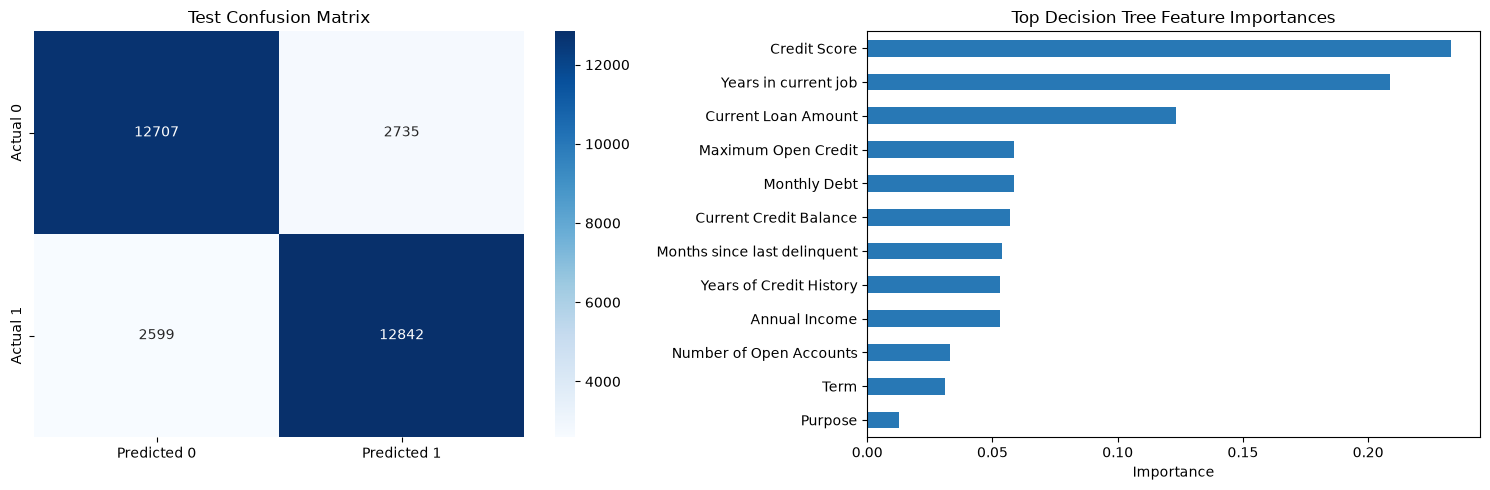

In [17]:
#  Plot the confusion matrix and feature importance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Test Confusion Matrix")

feature_importance = pd.Series(dt_clf.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False).head(12).sort_values().plot.barh(ax=axes[1], color="#2878b5")
axes[1].set_title("Top Decision Tree Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 10F. ROC Curve

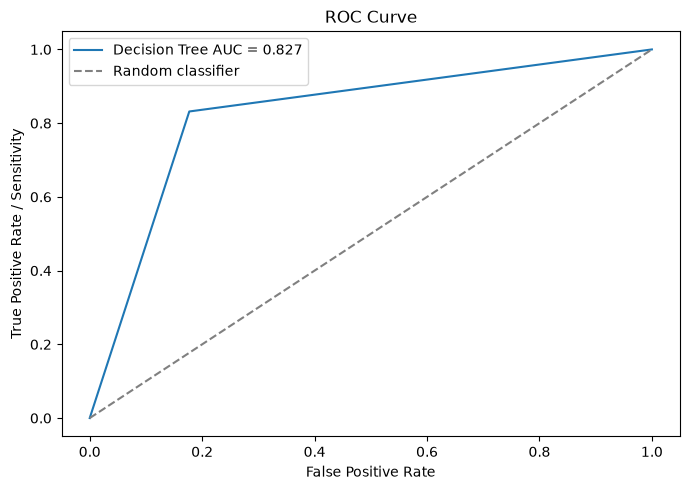

In [20]:
# 10F. Plot ROC curve and calculate AUC
false_positive_rate, true_positive_rate, _ = roc_curve(Y_test, y_test_probability)
roc_auc = roc_auc_score(Y_test, y_test_probability)

plt.figure(figsize=(7, 5))
plt.plot(false_positive_rate, true_positive_rate, label=f"Decision Tree AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#  Quick train/test accuracy check
print(f"Training accuracy: {accuracy_score(Y_train, y_train_pred):.4f}")
print(f"Testing accuracy: {accuracy_score(Y_test, y_test_pred):.4f}")

Training accuracy: 1.0000
Testing accuracy: 0.8273


## 10G. Save the Tuned Decision Tree as a Pickle File

In [21]:
# 10G. Export the trained Decision Tree and metadata in one file
import pickle

model_package = {
    "model": dt_clf,
    "feature_names": list(X_train.columns),
    "target_name": "Loan Status",
    "best_parameters": tree_search.best_params_,
    "metrics": performance_table.to_dict(orient="records"),
}

with open("decision_tree_credit_model.pkl", "wb") as file:
    pickle.dump(model_package, file)

print("Saved decision_tree_credit_model.pkl")

Saved decision_tree_credit_model.pkl
